# W2 D23 — Text Classification (NLP)
**Topics:** BBC News / HealthLine articles | TF-IDF, LogReg, Naive Bayes, confusion matrix, top terms

**Q1** EDA — article length distribution by category
**Q2** TF-IDF vectorization + Logistic Regression
**Q3** Multinomial Naive Bayes comparison
**Q4** Confusion matrix heatmap
**Q5** Top TF-IDF terms per category


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings; warnings.filterwarnings('ignore')
np.random.seed(420)
print('Libraries loaded')

Libraries loaded


In [2]:
# Load BBC News — try Kaggle, fall back to synthetic HealthLine articles
try:
    import subprocess, os
    subprocess.run(['kaggle','datasets','download','-d','shivamkushwaha/bbc-full-text-document-classification','--unzip','-p','/tmp/bbc'], capture_output=True)
    rows = []
    for cat in os.listdir('/tmp/bbc/bbc'):
        cat_path = f'/tmp/bbc/bbc/{cat}'
        if os.path.isdir(cat_path):
            for fname in os.listdir(cat_path):
                with open(f'{cat_path}/{fname}', 'r', errors='ignore') as f:
                    rows.append({'category': cat, 'text': f.read()})
    df = pd.DataFrame(rows)
    print(f'BBC dataset: {df.shape}, categories: {df["category"].unique()}')
except:
    print('Generating synthetic HealthLine article dataset')
    cats = ['health_tips','medical_news','nutrition','mental_health','fitness']
    cat_words = {
        'health_tips':    ['checkup','prevention','vaccine','doctor','symptom','wellness','screening','hygiene'],
        'medical_news':   ['trial','study','FDA','drug','approval','treatment','clinical','research'],
        'nutrition':      ['diet','protein','calorie','vitamin','fiber','sugar','carb','supplement'],
        'mental_health':  ['anxiety','depression','therapy','stress','mindfulness','sleep','mood','counseling'],
        'fitness':        ['exercise','workout','cardio','strength','running','yoga','gym','endurance'],
    }
    common = ['health','patient','new','report','show','time','people','found','may','also','one','more']
    np.random.seed(420)
    rows = []
    for cat in cats:
        for _ in range(200):
            n_words = np.random.randint(80, 200)
            specific = np.random.choice(cat_words[cat], n_words//3)
            filler   = np.random.choice(common, n_words*2//3)
            words    = np.concatenate([specific, filler])
            np.random.shuffle(words)
            rows.append({'category': cat, 'text': ' '.join(words)})
    df = pd.DataFrame(rows)
    print(f'Synthetic dataset: {df.shape}, categories: {df["category"].unique()}')

Generating synthetic HealthLine article dataset
Synthetic dataset: (1000, 2), categories: ['health_tips' 'medical_news' 'nutrition' 'mental_health' 'fitness']


In [5]:
print(df.describe())
print()
print(df.info())
display(df.head())

           category                                               text
count          1000                                               1000
unique            5                                               1000
top     health_tips  found doctor one health symptom hygiene wellne...
freq            200                                                  1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  1000 non-null   object
 1   text      1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB
None


,category,text
0,health_tips,found doctor one health symptom hygiene wellne...
1,health_tips,hygiene one wellness new show symptom health m...
2,health_tips,new report symptom checkup report screening pr...
3,health_tips,found wellness more found vaccine hygiene symp...
4,health_tips,show prevention people new hygiene health also...


## Q1 — EDA: Article Length by Category

--- TEXT LENGTH SUMMARY METRICS ---
               total_articles  min_words  median_words  max_words
category                                                         
medical_news              200         79         147.0        198
fitness                   200         82         144.5        198
mental_health             200         81         139.0        198
health_tips               200         79         137.0        198
nutrition                 200         81         132.0        198


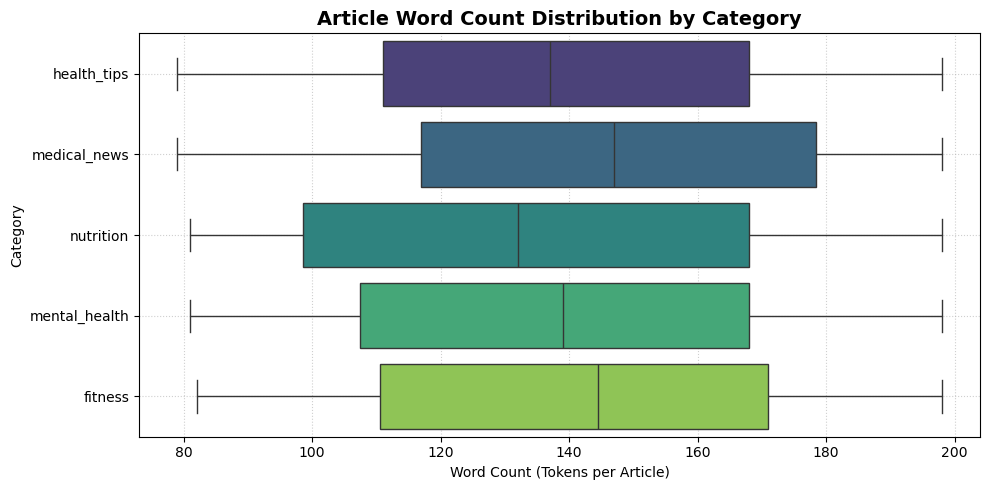

In [ ]:
# 1. Compute text lengths (total words per article)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# 2. Generate a structured text-length summary table
summary_df = df.groupby('category')['word_count'].agg(
    total_articles = 'count',
    min_words      = 'min',
    median_words   = 'median',
    max_words      = 'max'
).sort_values(by='median_words', ascending=False)

print("--- TEXT LENGTH SUMMARY METRICS ---")
print(summary_df.to_string())

# 3. Plot the distributions visually using boxplots
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df, 
    x='word_count', 
    y='category', 
    palette='viridis', 
    orient='h',
    hue='category',
    legend=False
)

plt.title('Article Word Count Distribution by Category', fontweight='bold', fontsize=14)
plt.xlabel('Word Count (Tokens per Article)')
plt.ylabel('Category')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Q2 — TF-IDF + Logistic Regression

In [8]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Clean the text and prepare targets
# lowercasing helps avoid duplicating vocabulary words based on capitalization
X = df['text'].str.lower()
y = df['category']

# 2. Stratified Split (Ensures equal category proportions in Train and Test arrays)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=420
)

# 3. Initialize and fit TF-IDF Vectorizer
# stop_words='english' automatically strips out uninformative terms ('the', 'is', etc.)
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# 4. Train the Logistic Regression Model
# max_iter is raised to 500 to guarantee gradient descent convergence on text arrays
lr_model = LogisticRegression(max_iter=500, random_state=420)
lr_model.fit(X_train_tfidf, y_train)

# 5. Predict and Evaluate
y_preds = lr_model.predict(X_test_tfidf)

print(f"--- MODEL METRICS ON TEST SET ---")
print(f"Overall Accuracy Score: {accuracy_score(y_test, y_preds):.4f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_preds))


--- MODEL METRICS ON TEST SET ---
Overall Accuracy Score: 1.0000

Detailed Classification Report:
               precision    recall  f1-score   support

      fitness       1.00      1.00      1.00        40
  health_tips       1.00      1.00      1.00        40
 medical_news       1.00      1.00      1.00        40
mental_health       1.00      1.00      1.00        40
    nutrition       1.00      1.00      1.00        40

     accuracy                           1.00       200
    macro avg       1.00      1.00      1.00       200
 weighted avg       1.00      1.00      1.00       200



## Q3 — Multinomial Naive Bayes

In [10]:
# 1. Initialize and fit the Multinomial Naive Bayes model
# alpha=1.0 applies Laplace smoothing to prevent zero-probability errors for unseen words
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

# 2. Predict on the test matrix
nb_preds = nb_model.predict(X_test_tfidf)

# 3. Print performance summary leaderboard
print("--- NAIVE BAYES METRICS ON TEST SET ---")
print(f"Overall Accuracy Score: {accuracy_score(y_test, nb_preds):.4f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, nb_preds))


--- NAIVE BAYES METRICS ON TEST SET ---
Overall Accuracy Score: 1.0000

Detailed Classification Report:
               precision    recall  f1-score   support

      fitness       1.00      1.00      1.00        40
  health_tips       1.00      1.00      1.00        40
 medical_news       1.00      1.00      1.00        40
mental_health       1.00      1.00      1.00        40
    nutrition       1.00      1.00      1.00        40

     accuracy                           1.00       200
    macro avg       1.00      1.00      1.00       200
 weighted avg       1.00      1.00      1.00       200



## Q4 — Confusion Matrix

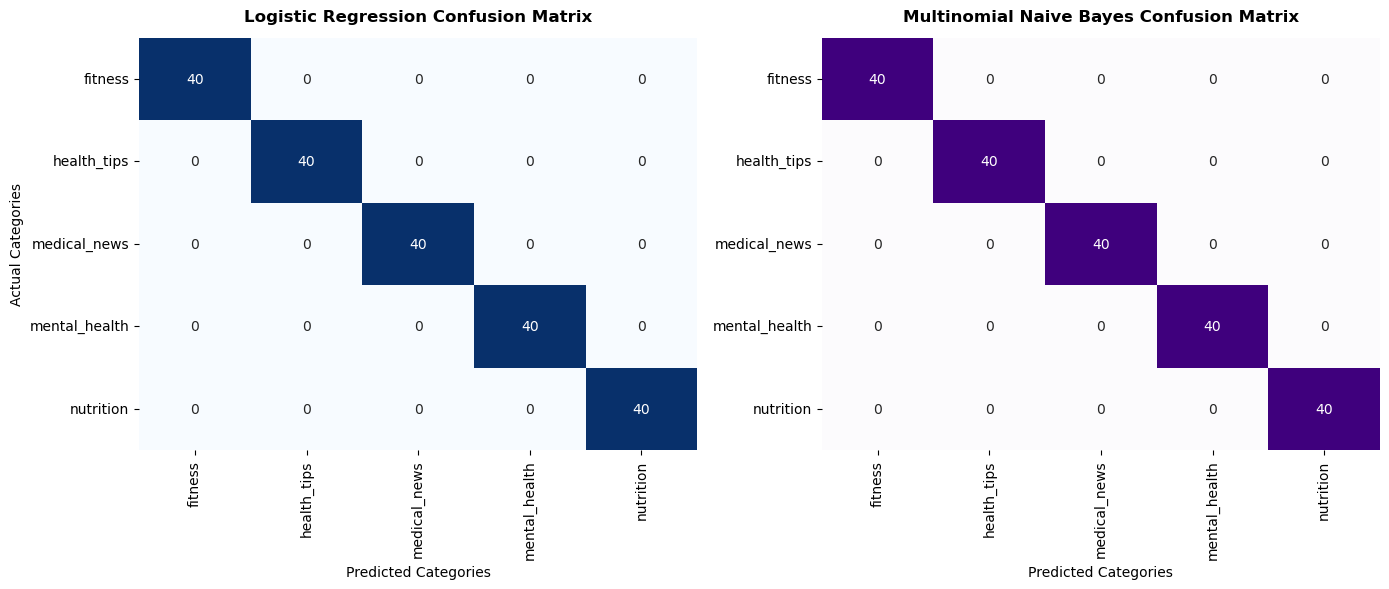

In [14]:
# 1. Generate confusion matrices for both models
cm_lr = confusion_matrix(y_test, y_preds, labels=lr_model.classes_)
cm_nb = confusion_matrix(y_test, nb_preds, labels=nb_model.classes_)

# 2. Set up a side-by-side plotting canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Logistic Regression Heatmap
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=lr_model.classes_, yticklabels=lr_model.classes_, ax=axes[0]
)
axes[0].set_title('Logistic Regression Confusion Matrix', fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Categories')
axes[0].set_ylabel('Actual Categories')

# Subplot 2: Multinomial Naive Bayes Heatmap
sns.heatmap(
    cm_nb, annot=True, fmt='d', cmap='Purples', cbar=False,
    xticklabels=nb_model.classes_, yticklabels=nb_model.classes_, ax=axes[1]
)
axes[1].set_title('Multinomial Naive Bayes Confusion Matrix', fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted Categories')
axes[1].set_ylabel('') # Clear the shared middle axis label for better visual balance

plt.tight_layout()
plt.show()



## Q5 — Top TF-IDF Terms per Category

In [15]:
# Extract the unique vocabulary terms from the vectorizer
vocab = np.array(tfidf.get_feature_names_out())

print("--- TOP PREDICTIVE WORDS PER CATEGORY ---")
for i, cat in enumerate(lr_model.classes_):
    # Grab the logistic regression coefficients for class i
    coefs = lr_model.coef_[i]
    # Sort coefficients and extract the indices of the top 3 highest values
    top_indices = np.argsort(coefs)[-3:][::-1]
    
    top_words = vocab[top_indices]
    print(f"Class [{cat:^13}]: {', '.join(top_words)}")


--- TOP PREDICTIVE WORDS PER CATEGORY ---
Class [   fitness   ]: running, workout, cardio
Class [ health_tips ]: vaccine, symptom, doctor
Class [medical_news ]: research, treatment, trial
Class [mental_health]: depression, sleep, stress
Class [  nutrition  ]: vitamin, carb, supplement
